In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Wine dataset.csv to Wine dataset.csv


import dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import dataset

In [ ]:
dataset = pd.read_csv('Wine dataset.csv')

splitting dataset into feature and target

In [ ]:
X = dataset.iloc[:,:-1].values
Y = dataset.iloc[:,-1].values


splitting dataset into training and test set 80 20

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

applying PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
print(pca)

PCA(n_components=2)


In [ ]:
print("Eigenvalues:")
print(pca.explained_variance_)

Eigenvalues:
[5.34689275 2.20792546]


In [ ]:
print("Eigenvectors:")
print(pca.components_)

Eigenvectors:
[[1. 0.]
 [0. 1.]]


In [ ]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.70774605 0.29225395]


training logistic regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)


LogisticRegression(random_state=0)

predicting test results

In [ ]:
y_pred = classifier.predict(X_test)

confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


visualization of decision boundary

/tmp/ipykernel_305/2415651390.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


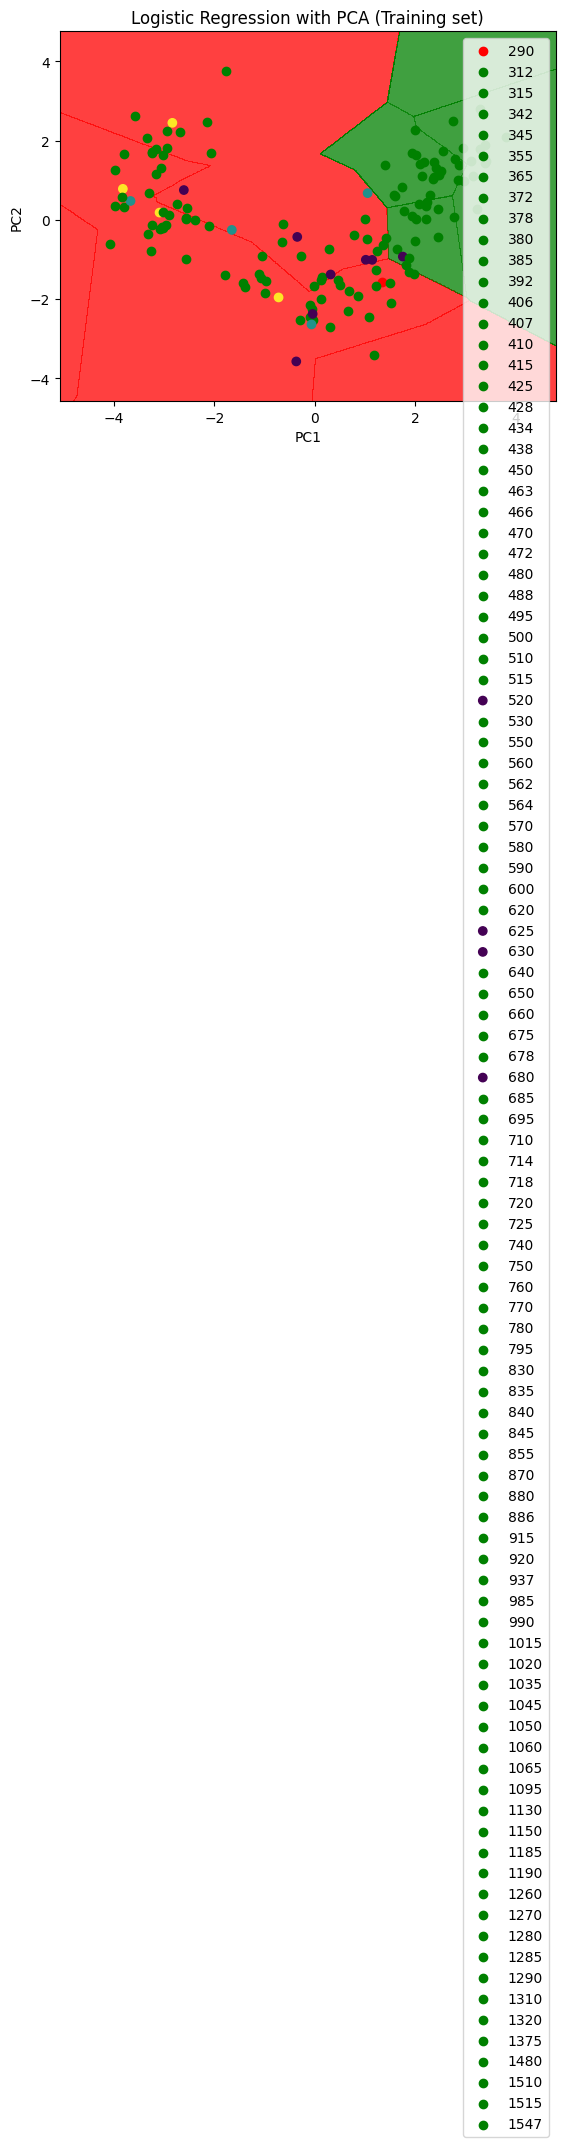

In [ ]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:,0].min()-1, stop=X_set[:,0].max()+1, step=0.01),
    np.arange(start=X_set[:,1].min()-1, stop=X_set[:,1].max()+1, step=0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red','green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red','green'))(i),
        label=j
    )

plt.title('Logistic Regression with PCA (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()